# MuTap — ITU-T echo-canceller compliance, proven

MuTap's acoustic echo canceller — `mutap::aec_chain`, the raw partitioned
frequency-domain **Kalman** canceller plus the coherence-driven
**residual suppressor** and **comfort noise** of `mutap/postfilter.h` —
claims compliance against the in-force ITU-T automotive/hands-free
requirements. A claim needs proof; this notebook is it.

Every number below is **measured live**: the first cell compiles a small
C++ battery ([`tools/notebook/itu_dump.cpp`](../tools/notebook/itu_dump.cpp))
that re-runs the compliance scenarios on the exact pinned chain the test
suite uses — same signals (P.501 CSS, AM-FM orthogonal pairs, Hoth and
driving noise), same meters (dBm0/dBm0(A), 35 ms and 5 ms integration),
same rooms (the image-source car cabin and the studio) — and this
notebook only *renders* what that battery measured. Nothing is
re-implemented in Python; nothing is pasted in by hand. The scenario
recipes mirror the gtest rows in [`tests/`](../tests) line for line, and
those tests remain the assertion authority in CI.

**What is claimed, and how honestly:**

- One chain configuration (`tests/support/itu_chain.h`), both required
  rates — **48 kHz** (automotive wideband) and **16 kHz** (wideband
  telephony, echo paths converted with P.501's NOTE 2 resampler).
- Requirement values are transcribed from the recommendations
  (P.1110/P.1120 §11.11-11.14, P.340 Table 5, G.168 figures 9/10/11,
  G.167 historical); *targets* are our own margin policy — at least
  6 dB of level margin or half the allowed time, whichever applies.
- Where a reading misses **our own target** while clearing the ITU
  **requirement**, it is marked **(T)** and explained — never silently.
- G.168 disclaims acoustic scope, so that battery is reported as
  **"G.168-adapted"**, never as G.168 compliance; G.167 is withdrawn and
  its bracketed values are **run and reported**, not claimed.
- Compressed real speech (P.501 annex WAVs) is method-equivalent
  pending procurement; the synthetic CSS/AM-FM signals used here are
  generated from the recommendations' algorithmic descriptions.

The full requirements matrix with clause-by-clause notes lives in
[`docs/itu-compliance.md`](../docs/itu-compliance.md).


In [1]:
import json, pathlib, subprocess, sys, time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

REPO = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
BUILD = REPO / "build-itu"   # dedicated dir: tests stay out of this cache
JSON_PATH = BUILD / "itu_dump.json"

def _run(cmd):
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.returncode != 0:
        print(r.stdout); print(r.stderr, file=sys.stderr)
        raise RuntimeError("command failed: " + " ".join(map(str, cmd)))
    return r

if not (BUILD / "CMakeCache.txt").exists():
    _run(["cmake", "-B", str(BUILD), "-S", str(REPO), "-DCMAKE_BUILD_TYPE=Release",
          "-DMUTAP_BUILD_ITU_DUMP=ON", "-DMUTAP_BUILD_TESTS=OFF"])
_run(["cmake", "--build", str(BUILD), "--target", "itu_dump", "--config", "Release", "-j"])
exe = next(p for p in sorted(BUILD.rglob("itu_dump*")) if p.is_file() and p.suffix in ("", ".exe"))

t0 = time.time()
_run([str(exe), str(JSON_PATH)])   # the measurement run: ~2-4 minutes, deterministic seeds
D = json.loads(JSON_PATH.read_text())
R = {int(r["fs"]): r for r in D["rates"]}
R48, R16 = R[48000], R[16000]
print(f"battery re-measured in {time.time() - t0:.0f} s — "
      f"48 kHz: block {R48['block']:.0f}/{R48['taps']:.0f} taps, "
      f"16 kHz: block {R16['block']:.0f}/{R16['taps']:.0f} taps")

# ---- shared plot/table style -------------------------------------------
C48, C16, C_REQ, C_TGT, C_GRAY = "#2a78d6", "#1baf7a", "#c0392b", "#eda100", "#52514e"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
                     "lines.linewidth": 1.8, "font.size": 10})

def trace(tr):
    """A dumped level trace -> (t, v) arrays."""
    v = np.asarray(tr["v"], dtype=float)
    return tr["t0"] + tr["dt"] * np.arange(len(v)), v

def table(headers, rows, caption=None):
    out = []
    if caption:
        out.append(f"**{caption}**\n")
    out.append("| " + " | ".join(headers) + " |")
    out.append("|" + "|".join(["---"] * len(headers)) + "|")
    for r in rows:
        out.append("| " + " | ".join(str(c) for c in r) + " |")
    display(Markdown("\n".join(out)))

def f1(v):  return f"{v:+.1f}" if v is not None else "—"
def m1(v):  return f"{v:.1f}"

def band_axis(ax):
    """Readable third-octave x-axis (the log minor labels collide)."""
    from matplotlib.ticker import NullFormatter, ScalarFormatter
    ax.set_xscale("log")
    ax.set_xticks([200, 500, 1000, 2000, 4000, 8000])
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.xaxis.set_minor_formatter(NullFormatter())

battery re-measured in 490 s — 48 kHz: block 256/2048 taps, 16 kHz: block 256/1024 taps


## 1. The device under test

One configuration is pinned for the whole battery — compliance for a
family of tunings is no compliance at all:

- **Canceller:** `mutap::partitioned_fdkf<double>`, block 256 at *both*
  rates (a scaled-down block 128 collapses the partitioned Kalman's
  convergence at 16 kHz — measured, and documented as an open
  investigation), 2048 taps at 48 kHz / 1024 at 16 kHz ≈ 43/64 ms of
  echo path, transition 0.9998, initial uncertainty 10.
- **Suppressor:** `mutap::residual_suppressor` at library defaults, with
  every per-block time constant rescaled so the *physical* time
  constants match across rates, the low-band suppression cap from
  300 Hz, and the comfort-noise floor bias calibrated per rate
  (4 at 48 kHz, 5.6 at 16 kHz — 16 ms blocks give the minimum-statistics
  window 3× fewer samples, biasing its minima deeper).
- **Chain policy:** the initial receive guard (switched < 14 dB send
  loss, only until convergence certifies, latched off permanently) —
  inside the switching allowance and forced by the convergence-in-noise
  clause, as section 3 shows.

Algorithmic delay is two blocks — **10.7 ms** at 48 kHz, **32 ms** at
16 kHz — against P.1110's 70 ms implementation budget.


## 2. Steady-state echo performance

Converged single talk: total coupling loss, absolute echo level on two
rooms, temporal stability of the attenuation, and the attenuation
*spectrum* against the wideband mask. The spectrum is the strictest way
to see the suppressor working: the mask demands 41-46 dB through the
speech band, and the chain clears it by double-digit margins at every
third-octave band.


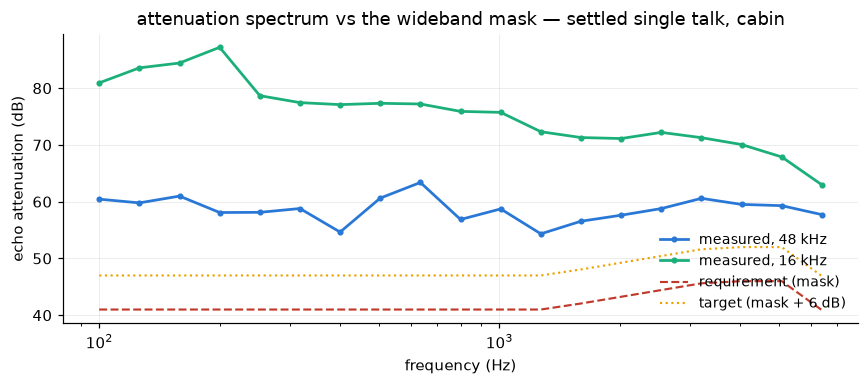

**Steady state — requirement / measured / margin. (T) marks a miss of our own target; every ITU requirement is met.**

| row | requirement | target | 48 kHz (margin) | 16 kHz (margin) |
|---|---|---|---|---|
| TCL (dB) | 46 | 52 | 68.4 (+22.4) | 79.9 (+33.9) |
| Echo level, cabin (dBm0(A)) | -58 | -64 | -76.4 (+18.4) | -80.9 (+22.9) |
| Echo level, studio (dBm0(A)) | -58 | -64 | -85.7 (+27.7) | -101.0 (+43.0) |
| Stability: attenuation variation (dB) | 6 | 3 | 2.7 (+3.3) | 3.9 (T) (+2.1) |
| Spectral margin over mask (dB) | 0 | 6 | 13.3 (+13.3) | 21.9 (+21.9) |

In [2]:
fig, ax = plt.subplots(figsize=(8, 3.6))
for r, col, lbl in ((R48, C48, "48 kHz"), (R16, C16, "16 kHz")):
    sp = r["echo"]["spectral"]
    ax.semilogx(sp["f"], sp["atten"], color=col, marker="o", ms=3, label=f"measured, {lbl}")
sp48 = R48["echo"]["spectral"]
ax.semilogx(sp48["f"], sp48["mask"], color=C_REQ, ls="--", lw=1.4, label="requirement (mask)")
ax.semilogx(sp48["f"], np.asarray(sp48["mask"]) + 6, color=C_TGT, ls=":", lw=1.4, label="target (mask + 6 dB)")
ax.set_xlabel("frequency (Hz)"); ax.set_ylabel("echo attenuation (dB)")
ax.set_title("attenuation spectrum vs the wideband mask — settled single talk, cabin")
ax.legend(fontsize=9, frameon=False, loc="lower right")
plt.tight_layout(); plt.show()

def spectral_worst(r):
    sp = r["echo"]["spectral"]
    return float(np.min(np.asarray(sp["atten"]) - np.asarray(sp["mask"])))

rows = []
for name, req, tgt, get, higher_is_better in [
    ("TCL (dB)",                        46.0, 52.0, lambda r: r["echo"]["tcl"],          True),
    ("Echo level, cabin (dBm0(A))",    -58.0, -64.0, lambda r: r["echo"]["level_cabin"],  False),
    ("Echo level, studio (dBm0(A))",   -58.0, -64.0, lambda r: r["echo"]["level_studio"], False),
    ("Stability: attenuation variation (dB)", 6.0, 3.0, lambda r: max(r["echo"]["stability_var"]), False),
    ("Spectral margin over mask (dB)",   0.0, 6.0, spectral_worst,                       True),
]:
    cells = [name, f"{req:g}", f"{tgt:g}"]
    for r in (R48, R16):
        v = get(r)
        ok_t = (v >= tgt) if higher_is_better else (v <= tgt)
        margin = (v - req) if higher_is_better else (req - v)
        cells.append(f"{v:.1f}{'' if ok_t else ' (T)'} ({f1(margin)})")
    rows.append(cells)
table(["row", "requirement", "target", "48 kHz (margin)", "16 kHz (margin)"], rows,
      "Steady state — requirement / measured / margin. (T) marks a miss of our own target; every ITU requirement is met.")

The one (T) in this section is temporal stability at 16 kHz: the
attenuation "varies" 4 dB at depths of 74-85 dB, where the variation is
the meter reading the suppressor floor, not echo coming back — the 6 dB
requirement holds with 2 dB to spare.

## 3. Convergence against the clock — Tier A

The recommendations' convergence rows are drawn as **masks over time**,
so this section plots the whole trajectory against them, not just the
scored points.

**Quiet convergence** (P.1110/P.1120 §11.11.4): echo-return loss from a
cold start must reach 40 dB by 1200 ms. The curves carry the measured
cost of a deliberate trade: the low-band suppression cap waits 0.3 s of
*sustained* coherence certification before releasing, which holds the
speech-heavy low bins down early — that certification bought P.340's
transfer-constancy **requirement** (section 5), and requirement outranks
our own half-time target.


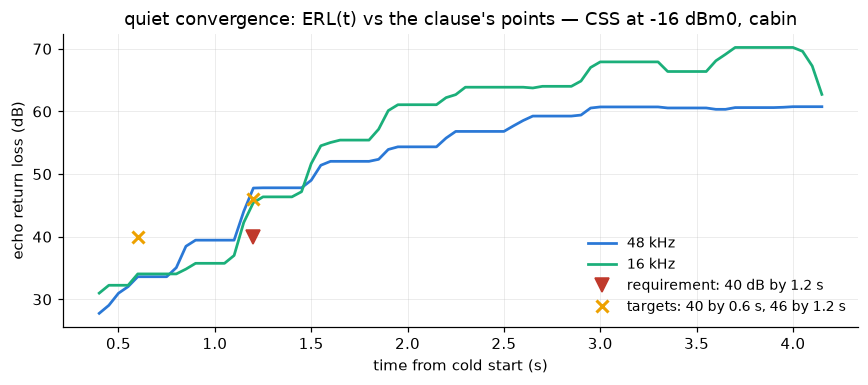

48 kHz: 33.6 dB at 600 ms, 47.8 dB at 1200 ms (requirement 40 at 1200 ms -> margin +7.8 dB)
16 kHz: 34.1 dB at 600 ms, 45.4 dB at 1200 ms (requirement 40 at 1200 ms -> margin +5.4 dB)


In [3]:
fig, ax = plt.subplots(figsize=(8, 3.6))
for r, col, lbl in ((R48, C48, "48 kHz"), (R16, C16, "16 kHz")):
    c = r["conv_quiet"]["curve"]
    ax.plot(c["t"], c["erl"], color=col, label=lbl)
ax.plot([1.2], [40], "v", color=C_REQ, ms=9, label="requirement: 40 dB by 1.2 s")
ax.plot([0.6, 1.2], [40, 46], "x", color=C_TGT, ms=8, mew=2, label="targets: 40 by 0.6 s, 46 by 1.2 s")
ax.set_xlabel("time from cold start (s)"); ax.set_ylabel("echo return loss (dB)")
ax.set_title("quiet convergence: ERL(t) vs the clause's points — CSS at -16 dBm0, cabin")
ax.legend(fontsize=9, frameon=False, loc="lower right")
plt.tight_layout(); plt.show()
for r, lbl in ((R48, "48 kHz"), (R16, "16 kHz")):
    q = r["conv_quiet"]
    print(f"{lbl}: {q['by600']:.1f} dB at 600 ms, {q['by1200']:.1f} dB at 1200 ms "
          f"(requirement 40 at 1200 ms -> margin {q['by1200'] - 40:+.1f} dB)")

**Convergence in noise** (§11.11.5) is the row that *designed part of
the chain*. A fresh canceller passes raw echo, and no suppressor that
references the echo estimate can see echo the canceller hasn't modeled —
so the chain opens with a switched send loss (< 14 dB, inside the
A_H,S < 20 dB switching allowance) that latches off permanently once
convergence certifies. The scenario is the clause's own condition class:
synthetic driving noise at −30 dBm0(A), transmitted-noise reference from
the pre-roll, same meter statistic. The mask: no more than ref + 10 dB
from 100 ms after the far end starts, back at the reference by 1500 ms
(requirement) / 750 ms (our target).


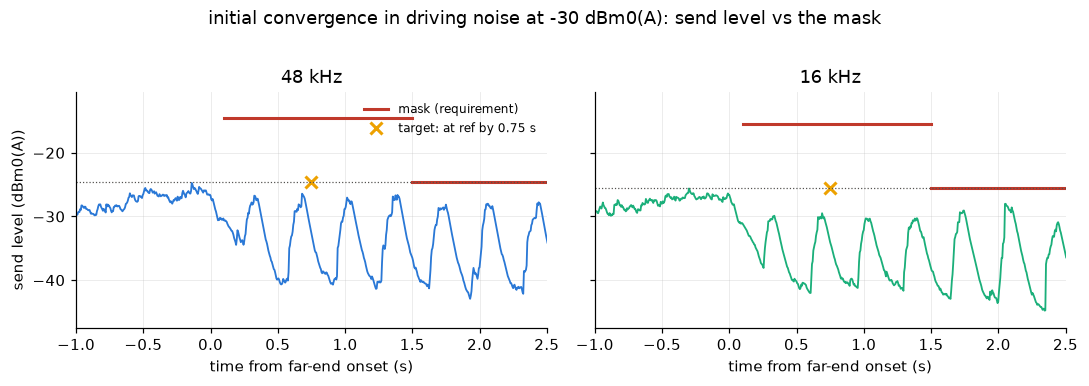

**Convergence in noise — every mask point met at both rates.**

| rate | reference (dBm0(A)) | max in first 100-200 ms | max 750-1000 ms (target ≤ ref) | max 1500-2000 ms (req ≤ ref) |
|---|---|---|---|---|
| 48 kHz | -24.5 | -30.6 (mask -14.5) | -28.6 | -28.1 |
| 16 kHz | -25.5 | -31.1 (mask -15.5) | -32.1 | -28.9 |

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True)
for ax, r, col, lbl in ((axes[0], R48, C48, "48 kHz"), (axes[1], R16, C16, "16 kHz")):
    cn = r["conv_noise"]
    t, v = trace(cn["trace"])
    ts = cn["t_start"]
    ax.plot(t - ts, v, color=col, lw=1.2)
    ref = cn["ref"]
    ax.plot([0.1, 1.5], [ref + 10, ref + 10], color=C_REQ, lw=2)
    ax.plot([1.5, t[-1] - ts], [ref, ref], color=C_REQ, lw=2, label="mask (requirement)")
    ax.plot([0.75], [ref], "x", color=C_TGT, ms=8, mew=2, label="target: at ref by 0.75 s")
    ax.axhline(ref, color=C_GRAY, ls=":", lw=0.8)
    ax.annotate("idle noise reference", (t[-1] - ts, ref), fontsize=8, color=C_GRAY,
                ha="right", va="bottom")
    ax.set_xlim(-1.0, 2.5); ax.set_ylim(ref - 22, ref + 15)  # the meter's silent-start warm-up is off-scale
    ax.set_xlabel("time from far-end onset (s)")
    ax.set_title(lbl)
axes[0].set_ylabel("send level (dBm0(A))")
axes[0].legend(fontsize=8, frameon=False, loc="upper right")
fig.suptitle("initial convergence in driving noise at -30 dBm0(A): send level vs the mask", y=1.02)
plt.tight_layout(); plt.show()

rows = []
for r, lbl in ((R48, "48 kHz"), (R16, "16 kHz")):
    cn = r["conv_noise"]
    rows.append([lbl, m1(cn["ref"]),
                 f"{cn['onset']:.1f} (mask {cn['ref'] + 10:.1f})",
                 f"{cn['by750']:.1f}", f"{cn['by1500']:.1f}"])
table(["rate", "reference (dBm0(A))", "max in first 100-200 ms", "max 750-1000 ms (target ≤ ref)",
       "max 1500-2000 ms (req ≤ ref)"], rows,
      "Convergence in noise — every mask point met at both rates.")

A quiet-background variant (Hoth at −46 dBm0) meets this mask only
from ~600 ms: with echo 30 dB above BGN + 10 at onset, the first mask
segment would demand more switched loss than the switching allowance
permits — recorded in the matrix as a scenario note, not asserted.

## 4. Convergence, the G.168-adapted way

G.168 draws its convergence bounds as figures: **Figure 9** bounds the
returned echo level with the NLP on (here: the chain with comfort noise
disabled, Figure 9's own instruction), **Figure 11** with the NLP off
(here: the bare canceller). Conventions from the matrix: cabin path
scaled to ERL = 6 dB coupling, levels are LRin,act, G.168's 35 ms
unweighted meter.


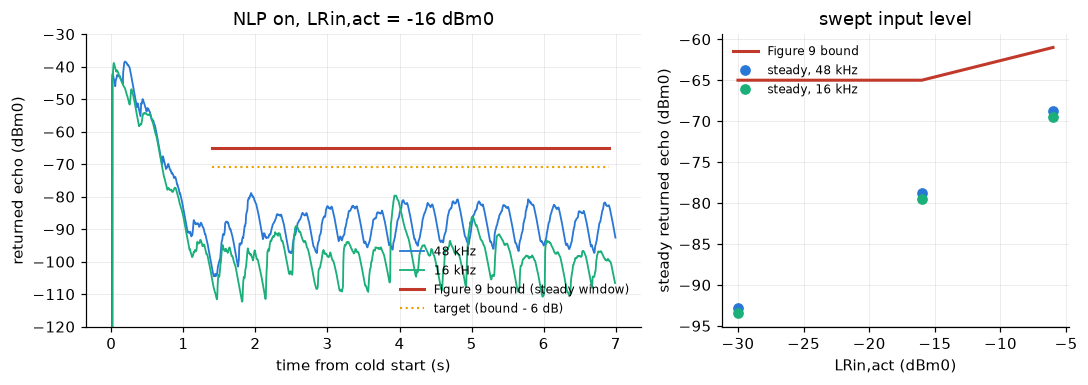

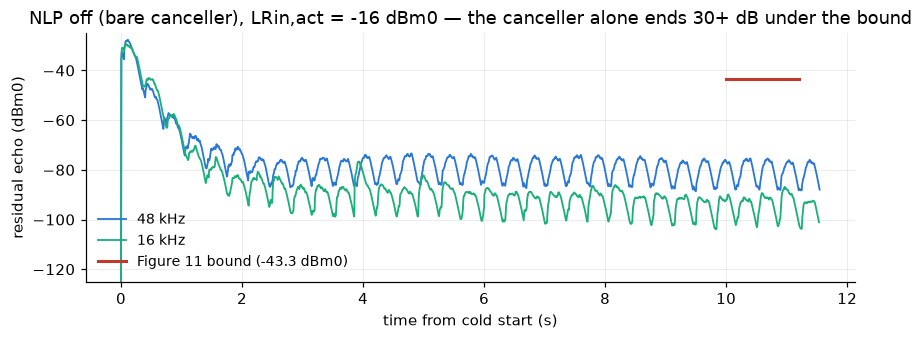

**G.168-adapted convergence, worst level of the sweep — combined-loss elements and the figures' bounds.**

| rate | NLP on: loss 0-50 ms (≥ 6) | loss 50 ms-1 s (≥ 20) | steady vs Fig 9 (≤ 0) | NLP off: loss 0-50 ms (≥ 6) | loss 1-10 s (≥ 20) | steady vs Fig 11 (≤ 0) |
|---|---|---|---|---|---|---|
| 48 kHz | 26.3 | 22.3 | -7.8 | 16.5 | 49.3 | -31.9 |
| 16 kHz | 22.6 | 23.9 | -8.5 | 14.6 | 50.1 | -43.5 |

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.6), gridspec_kw={"width_ratios": [1.6, 1]})
for r, col, lbl in ((R48, C48, "48 kHz"), (R16, C16, "16 kHz")):
    t, v = trace(r["fig9"]["trace16"])
    ax1.plot(t, v, color=col, lw=1.2, label=lbl)
f9_16 = R48["fig9"]["mask"][R48["fig9"]["levels"].index(-16.0)]
ax1.plot([1.4, 6.9], [f9_16, f9_16], color=C_REQ, lw=2, label="Figure 9 bound (steady window)")
ax1.plot([1.4, 6.9], [f9_16 - 6, f9_16 - 6], color=C_TGT, ls=":", lw=1.4, label="target (bound - 6 dB)")
ax1.set_xlabel("time from cold start (s)"); ax1.set_ylabel("returned echo (dBm0)")
ax1.set_ylim(-120, -30)  # the meter's silent-start warm-up is off-scale
ax1.set_title("NLP on, LRin,act = -16 dBm0")
ax1.legend(fontsize=8, frameon=False, loc="lower right")

lv = np.asarray(R48["fig9"]["levels"])
ax2.plot(lv, R48["fig9"]["mask"], color=C_REQ, lw=2, label="Figure 9 bound")
for r, col, lbl in ((R48, C48, "48 kHz"), (R16, C16, "16 kHz")):
    ax2.plot(lv, r["fig9"]["steady"], "o", color=col, label=f"steady, {lbl}")
ax2.set_xlabel("LRin,act (dBm0)"); ax2.set_ylabel("steady returned echo (dBm0)")
ax2.set_title("swept input level")
ax2.legend(fontsize=8, frameon=False, loc="upper left")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(8, 3.2))
for r, col, lbl in ((R48, C48, "48 kHz"), (R16, C16, "16 kHz")):
    t, v = trace(r["fig11"]["trace"])
    ax.plot(t, v, color=col, lw=1.2, label=lbl)
f11 = R48["fig11"]["mask"]
ax.plot([10.0, 11.2], [f11, f11], color=C_REQ, lw=2, label=f"Figure 11 bound ({f11:.1f} dBm0)")
ax.set_xlabel("time from cold start (s)"); ax.set_ylabel("residual echo (dBm0)")
ax.set_ylim(-125, -25)
ax.set_title("NLP off (bare canceller), LRin,act = -16 dBm0 — the canceller alone ends 30+ dB under the bound")
ax.legend(fontsize=9, frameon=False, loc="lower left")
plt.tight_layout(); plt.show()

rows = []
for r, lbl in ((R48, "48 kHz"), (R16, "16 kHz")):
    f9, f11d = r["fig9"], r["fig11"]
    worst9 = max(s - m for s, m in zip(f9["steady"], f9["mask"]))
    rows.append([lbl, m1(min(f9["loss50"])), m1(min(f9["loss1s"])), f"{worst9:+.1f}",
                 m1(f11d["loss50"]), m1(f11d["loss_1_10"]), f"{f11d['steady'] - f11d['mask']:+.1f}"])
table(["rate", "NLP on: loss 0-50 ms (≥ 6)", "loss 50 ms-1 s (≥ 20)", "steady vs Fig 9 (≤ 0)",
       "NLP off: loss 0-50 ms (≥ 6)", "loss 1-10 s (≥ 20)", "steady vs Fig 11 (≤ 0)"], rows,
      "G.168-adapted convergence, worst level of the sweep — combined-loss elements and the figures' bounds.")

### Re-convergence after an abrupt path change — the rescue's two triggers

Swap the room mid-call (cabin at 6 dB coupling → studio at 16 dB, no
reset). A converged Kalman's structural failure mode here is a
self-lock: its state uncertainty is orders of magnitude below the
cold-start value, and within ~100 ms its noise tracker absorbs the
unmodeled-echo residual — the filter books its own error as near-end
noise and re-converges at a gain ~20× too small (the deep steady state
used to take ~7 s at 48 kHz and > 10 s at 16 kHz, where a cold start
takes 1.4 s).

The chain's **re-convergence rescue** closes this, from two
independent triggers that share one action — lift the canceller's
uncertainty back to its cold-start value once (weights kept, 2 s
cooldown) — and cover the two directions a path can change:

- **Over-explanation** (quieter path): the suppressor's
  echo-explained ratio shows the estimate *exceeding* the mic,
  sustained — the one mismatch signal a near end cannot fake, since
  double talk only *adds* mic power.
- **Shadow comparator** (louder path): a tiny 2-partition shadow
  canceller with a fast state leak runs on the same signals; it never
  converges deep, but after a swap it re-acquires the coarse path in
  ~100 ms while the locked main filter cannot. When the main
  residual sits 3 dB above the shadow's, sustained ~0.3 s of
  receive activity, the main filter is provably beaten by a worse
  filter — double-talk-immune by construction, because near-end
  speech lands in both residuals. Detector variants that instead
  tried to read the mismatch from the main filter's own innovations
  all lost to the P.501 AM-FM combs; their measured failures are
  recorded in [`HANDOFF.md`](../HANDOFF.md) and `fd_kalman.h`.

With both triggers the descent after a swap in either direction runs
at cold-start speed.


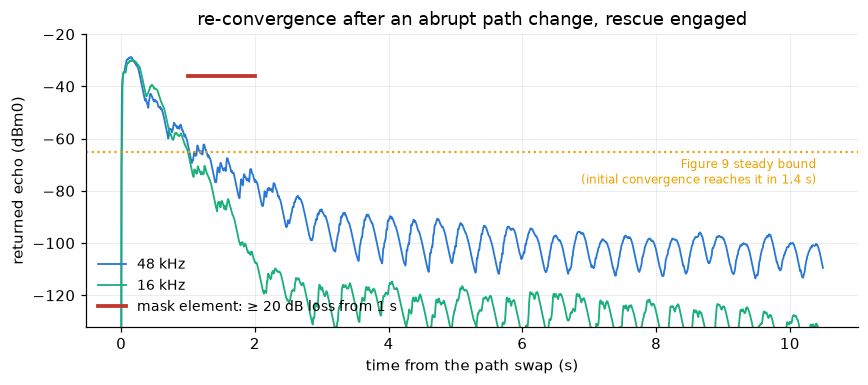

48 kHz: loss 12.7 dB in [0,1] s, 46.1 dB in [1,2] s (mask ≥ 20); returned echo -95.9 dBm0 in [8,10.5] s
16 kHz: loss 14.0 dB in [0,1] s, 49.2 dB in [1,2] s (mask ≥ 20); returned echo -123.3 dBm0 in [8,10.5] s


In [6]:
fig, ax = plt.subplots(figsize=(8, 3.6))
for r, col, lbl in ((R48, C48, "48 kHz"), (R16, C16, "16 kHz")):
    t, v = trace(r["reconv"]["trace"])
    ax.plot(t, v, color=col, lw=1.2, label=lbl)
l = R48["reconv"]["level"]
ax.plot([1.0, 2.0], [l - 20, l - 20], color=C_REQ, lw=2.5, label="mask element: ≥ 20 dB loss from 1 s")
ax.axhline(-65, color=C_TGT, ls=":", lw=1.4)
ax.annotate("Figure 9 steady bound\n(initial convergence reaches it in 1.4 s)",
            (10.4, -67), fontsize=8, color=C_TGT, ha="right", va="top")
ax.set_xlabel("time from the path swap (s)"); ax.set_ylabel("returned echo (dBm0)")
ax.set_ylim(-132, -20)
ax.set_title("re-convergence after an abrupt path change, rescue engaged")
ax.legend(fontsize=9, frameon=False, loc="lower left")
plt.tight_layout(); plt.show()
for r, lbl in ((R48, "48 kHz"), (R16, "16 kHz")):
    rc = r["reconv"]
    print(f"{lbl}: loss {rc['loss_0_1']:.1f} dB in [0,1] s, {rc['loss_1_2']:.1f} dB in [1,2] s "
          f"(mask ≥ 20); returned echo {rc['steady_8_105']:.1f} dBm0 in [8,10.5] s")

## 5. Double talk against the P.340 windows

P.340 Table 5, Category 1 (full duplex): while both ends talk, the near
talker must pass essentially unattenuated *and* the echo must stay
cancelled — with no double-talk detector to arbitrate. The measurement
uses P.501 §7.2.4's AM-FM **orthogonal comb pair**: far end and near end
occupy interleaved frequency combs, so one recording separates the
near-end speech from the echo it overlaps in time.

The suppressor's double-talk transparency is the *shape of the rule*,
not a detector: suppression depth comes from a coherence-gated leakage
estimate, and near-end energy destroys exactly the coherence that would
justify suppressing.


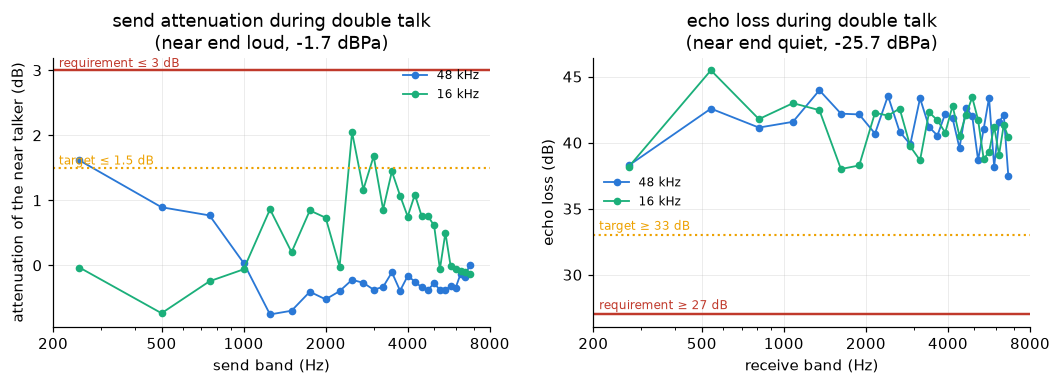

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.6))
for r, col, lbl in ((R48, C48, "48 kHz"), (R16, C16, "16 kHz")):
    b = r["dt"]["send_bands"]
    ax1.plot(b["f"], b["atten"], "o-", color=col, ms=4, lw=1.2, label=lbl)
ax1.axhline(3.0, color=C_REQ, lw=1.6); ax1.annotate("requirement ≤ 3 dB", (210, 3.05), fontsize=8, color=C_REQ)
ax1.axhline(1.5, color=C_TGT, ls=":", lw=1.4); ax1.annotate("target ≤ 1.5 dB", (210, 1.55), fontsize=8, color=C_TGT)
band_axis(ax1); ax1.set_xlabel("send band (Hz)"); ax1.set_ylabel("attenuation of the near talker (dB)")
ax1.set_title("send attenuation during double talk\n(near end loud, -1.7 dBPa)")
ax1.legend(fontsize=8, frameon=False)

for r, col, lbl in ((R48, C48, "48 kHz"), (R16, C16, "16 kHz")):
    b = r["dt"]["echo_loss_bands"]
    ax2.plot(b["f"], b["loss"], "o-", color=col, ms=4, lw=1.2, label=lbl)
ax2.axhline(27.0, color=C_REQ, lw=1.6); ax2.annotate("requirement ≥ 27 dB", (210, 27.4), fontsize=8, color=C_REQ)
ax2.axhline(33.0, color=C_TGT, ls=":", lw=1.4); ax2.annotate("target ≥ 33 dB", (210, 33.4), fontsize=8, color=C_TGT)
band_axis(ax2); ax2.set_xlabel("receive band (Hz)"); ax2.set_ylabel("echo loss (dB)")
ax2.set_title("echo loss during double talk\n(near end quiet, -25.7 dBPa)")
ax2.legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

**Transfer-function constancy** (P.340 Behaviour 1): the send path's
transfer function must not change by more than ±3 dB between double talk
and near-end single talk — the row that forced the low-band suppression
cap and its sustained certification (and, en route, exposed a simulation
artifact: with a shared PN seed the "independent" far end partially
predicts the near end, so the scenario decorrelates the seeds).

**Hangover** and **build-up** are the timeline rows: how fast full echo
attenuation returns once the near end stops, and how fast the send path
opens when the near end starts from idle.


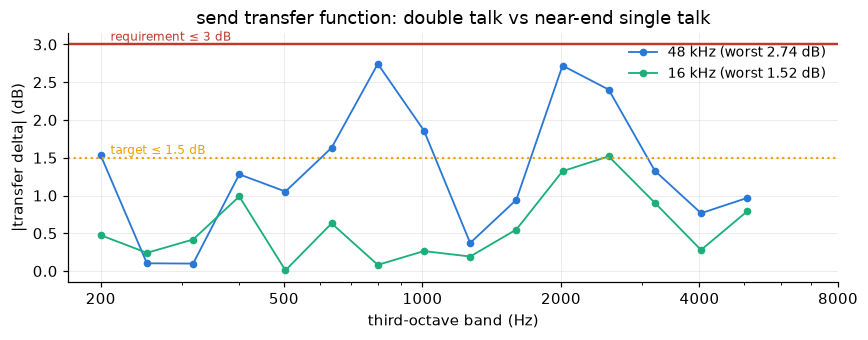

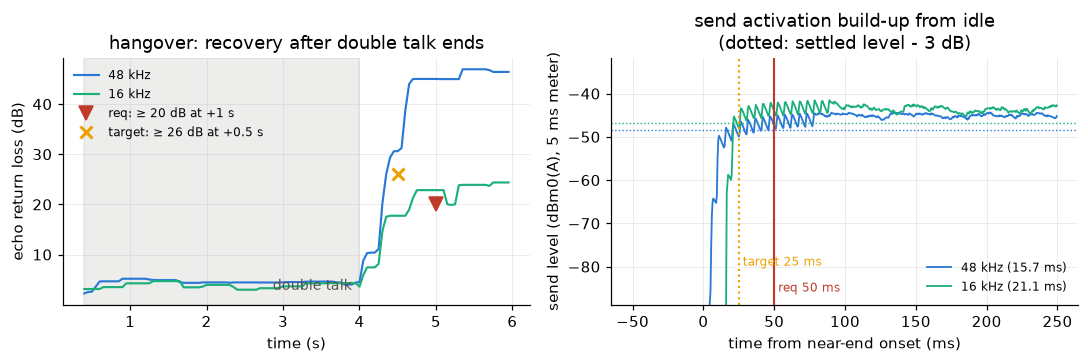

**Double talk and switching — requirement / target / measured.**

| rate | DT send atten, integrated (≤ 3 / 1.5) | worst band (≤ 3) | DT echo loss, worst band (≥ 27 / 33) | transfer delta (≤ 3 / 1.5) | hangover +0.5 s (target ≥ 26) | +1 s (req ≥ [20]) | build-up (≤ 50 / 25 ms) |
|---|---|---|---|---|---|---|---|
| 48 kHz | 0.9 | 1.6 | 37.5 | 2.74 | 30.6 | 45.0 | 15.7 |
| 16 kHz | -0.2 | 2.0 | 38.0 | 1.52 | 17.7 (T) | 22.8 | 21.1 |

In [8]:
fig, ax = plt.subplots(figsize=(8, 3.2))
for r, col, lbl in ((R48, C48, "48 kHz"), (R16, C16, "16 kHz")):
    t1 = r["dt"]["type1"]
    ax.semilogx(t1["f"], np.abs(np.asarray(t1["dt"]) - np.asarray(t1["st"])), "o-", color=col, ms=4, lw=1.2,
                label=f"{lbl} (worst {t1['worst']:.2f} dB)")
ax.axhline(3.0, color=C_REQ, lw=1.6); ax.annotate("requirement ≤ 3 dB", (210, 3.05), fontsize=8, color=C_REQ)
ax.axhline(1.5, color=C_TGT, ls=":", lw=1.4); ax.annotate("target ≤ 1.5 dB", (210, 1.55), fontsize=8, color=C_TGT)
band_axis(ax); ax.set_xlabel("third-octave band (Hz)"); ax.set_ylabel("|transfer delta| (dB)")
ax.set_title("send transfer function: double talk vs near-end single talk")
ax.legend(fontsize=9, frameon=False)
plt.tight_layout(); plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.4))
for r, col, lbl in ((R48, C48, "48 kHz"), (R16, C16, "16 kHz")):
    h = r["dt"]["hangover"]
    ax1.plot(h["curve"]["t"], h["curve"]["erl"], color=col, lw=1.4, label=lbl)
t_end = R48["dt"]["hangover"]["t_end"]
ax1.axvspan(0.4, t_end, color=C_GRAY, alpha=0.10)
ax1.annotate("double talk", (t_end - 0.1, ax1.get_ylim()[1]*0.06 + ax1.get_ylim()[0]), fontsize=9,
             color=C_GRAY, ha="right")
ax1.plot([t_end + 1.0], [20], "v", color=C_REQ, ms=9, label="req: ≥ 20 dB at +1 s")
ax1.plot([t_end + 0.5], [26], "x", color=C_TGT, ms=8, mew=2, label="target: ≥ 26 dB at +0.5 s")
ax1.set_xlabel("time (s)"); ax1.set_ylabel("echo return loss (dB)")
ax1.set_title("hangover: recovery after double talk ends")
ax1.legend(fontsize=8, frameon=False, loc="upper left")

tgt_hi = max(r["dt"]["buildup"]["target"] for r in (R48, R16))
for r, col, lbl in ((R48, C48, "48 kHz"), (R16, C16, "16 kHz")):
    bu = r["dt"]["buildup"]
    t, v = trace(bu["trace"])
    ax2.plot(t * 1000, v, color=col, lw=1.2, label=f"{lbl} ({bu['t_hit_ms']:.1f} ms)")
    ax2.axhline(bu["target"] - 3.0, color=col, ls=":", lw=0.9)
ax2.set_ylim(tgt_hi - 45, tgt_hi + 12)  # the idle meter floor is off-scale
ax2.axvline(25, color=C_TGT, ls=":", lw=1.4); ax2.annotate(" target 25 ms", (25, tgt_hi - 36), fontsize=8, color=C_TGT)
ax2.axvline(50, color=C_REQ, lw=1.4); ax2.annotate(" req 50 ms", (50, tgt_hi - 42), fontsize=8, color=C_REQ)
ax2.set_xlabel("time from near-end onset (ms)"); ax2.set_ylabel("send level (dBm0(A), 5 ms meter)")
ax2.set_title("send activation build-up from idle\n(dotted: settled level - 3 dB)")
ax2.legend(fontsize=8, frameon=False, loc="lower right")
plt.tight_layout(); plt.show()

rows = []
for r, lbl in ((R48, "48 kHz"), (R16, "16 kHz")):
    dt = r["dt"]
    hb = dt["hangover"]
    t05 = "" if hb["at_05"] >= 26.0 else " (T)"
    rows.append([lbl, m1(dt["send_integ"]), m1(max(dt["send_bands"]["atten"])),
                 m1(min(dt["echo_loss_bands"]["loss"])), f"{dt['type1']['worst']:.2f}",
                 f"{hb['at_05']:.1f}{t05}", m1(hb["at_10"]), m1(dt["buildup"]["t_hit_ms"])])
table(["rate", "DT send atten, integrated (≤ 3 / 1.5)", "worst band (≤ 3)", "DT echo loss, worst band (≥ 27 / 33)",
       "transfer delta (≤ 3 / 1.5)", "hangover +0.5 s (target ≥ 26)", "+1 s (req ≥ [20])", "build-up (≤ 50 / 25 ms)"],
      rows, "Double talk and switching — requirement / target / measured.")

The (T) is 16 kHz hangover at the half-time point: recovery reaches
the provisional requirement on schedule but our half-time target late —
the same depth-vs-tracking trade pinned by the double-talk rows (and one
of the margins the filed uncertainty re-inflation follow-up would lift).
The chain performs **no receive-path processing**, so the receive-side
activation and attenuation-range rows are identically trivial (0 dB) and
recorded in the matrix rather than measured here.

## 6. Comfort noise and background noise

When the suppressor removes residual echo during far-end talk it also
removes the background noise under it; the comfort-noise fill must put
back noise at the right *level* and the right *spectrum*, or the far
talker hears the room breathe. The fill is driven by a two-window
minimum-statistics floor tracker — fill only, never subtraction.


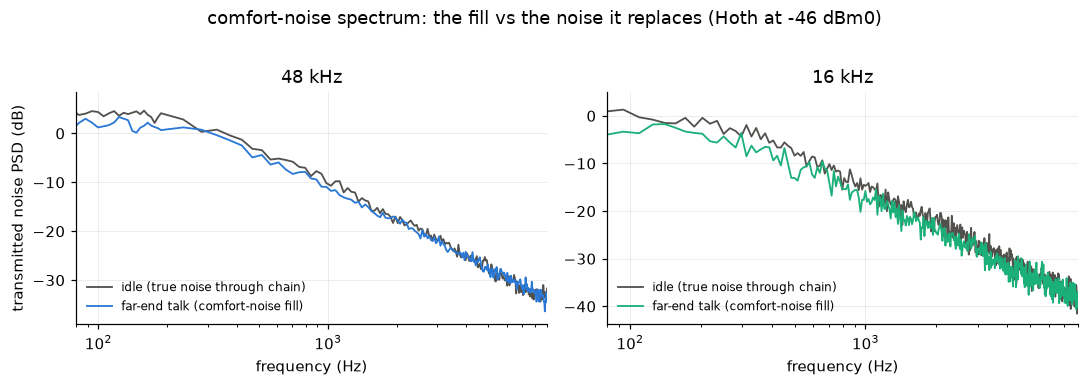

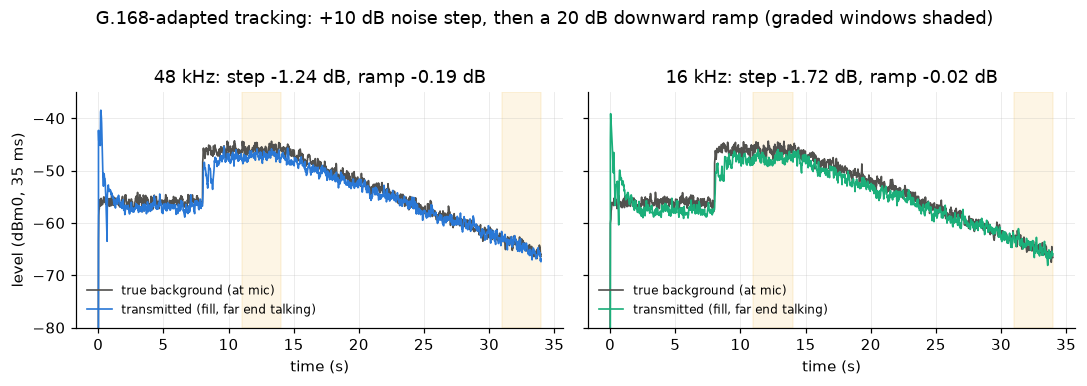

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), sharey=False)
for ax, r, col, lbl in ((axes[0], R48, C48, "48 kHz"), (axes[1], R16, C16, "16 kHz")):
    p = r["noise"]["cn_psd"]
    ax.semilogx(p["f"], p["quiet"], color=C_GRAY, lw=1.2, label="idle (true noise through chain)")
    ax.semilogx(p["f"], p["talk"], color=col, lw=1.2, label="far-end talk (comfort-noise fill)")
    ax.set_xlim(80, min(int(r["fs"]) / 2, 9000)); ax.set_xlabel("frequency (Hz)")
    ax.set_title(lbl); ax.legend(fontsize=8, frameon=False, loc="lower left")
axes[0].set_ylabel("transmitted noise PSD (dB)")
fig.suptitle("comfort-noise spectrum: the fill vs the noise it replaces (Hoth at -46 dBm0)", y=1.02)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True)
for ax, r, col, lbl in ((axes[0], R48, C48, "48 kHz"), (axes[1], R16, C16, "16 kHz")):
    ct = r["noise"]["cn_track"]
    tn, vn = trace(ct["trace_noise"]); to, vo = trace(ct["trace_out"])
    ax.plot(tn, vn, color=C_GRAY, lw=1.1, label="true background (at mic)")
    ax.plot(to, vo, color=col, lw=1.1, label="transmitted (fill, far end talking)")
    ax.axvspan(11, 14, color=C_TGT, alpha=0.10); ax.axvspan(31, 34, color=C_TGT, alpha=0.10)
    ax.set_ylim(-80, -35)  # the meter's silent-start warm-up is off-scale
    ax.set_xlabel("time (s)"); ax.set_title(f"{lbl}: step {ct['step_delta']:+.2f} dB, ramp {ct['ramp_delta']:+.2f} dB")
    ax.legend(fontsize=8, frameon=False, loc="lower left")
axes[0].set_ylabel("level (dBm0, 35 ms)")
fig.suptitle("G.168-adapted tracking: +10 dB noise step, then a 20 dB downward ramp (graded windows shaded)", y=1.02)
plt.tight_layout(); plt.show()

**Noise pumping** is the classic AEC artifact this section polices:
the background must not audibly duck and swell as far-end speech bursts
come and go. Driving noise at −30 dBm0(A), far-end CSS in 2 s on / 2 s
off bursts after 15 s of pre-conditioning, graded on per-segment average
levels (the rec compares segment levels, not meter extrema — the
instantaneous trace's swing belongs mostly to the synthetic noise's own
slow drift).


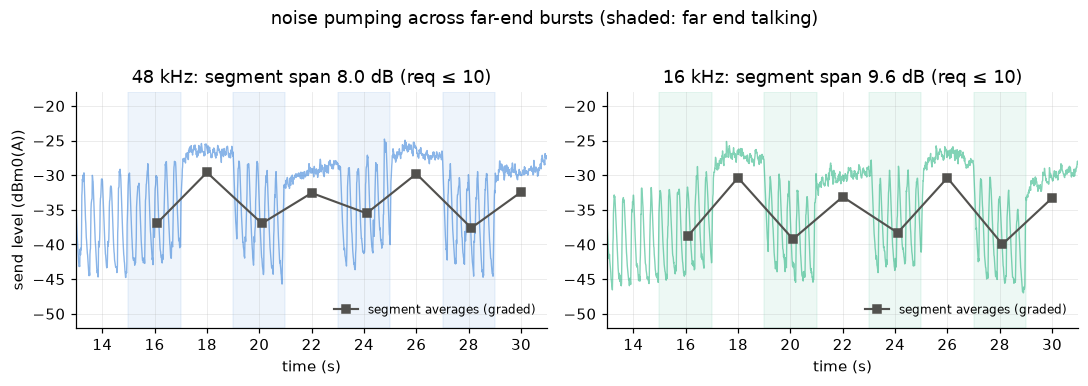

**Comfort noise and background noise. Half-mask targets: ±6 dB to 800 Hz, ±5 to 2 kHz, ±3 above.**

| rate | CN level delta (+2/-5, target +1/-2.5) | CN spectrum, worst band vs half-mask | noise fluctuation span (≤ 6 / 3.5) | pumping span (≤ 10 / 5) | CN step tracking (± 2) | CN ramp tracking (± 6) |
|---|---|---|---|---|---|---|
| 48 kHz | -1.31 | 1.58 | 3.1 | 8.0 (T) | -1.24 | -0.19 |
| 16 kHz | -2.15 | 2.93 | 3.1 | 9.6 (T) | -1.72 | -0.02 |

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), sharey=False)
for ax, r, col, lbl in ((axes[0], R48, C48, "48 kHz"), (axes[1], R16, C16, "16 kHz")):
    p = r["noise"]["pump"]
    t, v = trace(p["trace"])
    ax.plot(t, v, color=col, lw=0.9, alpha=0.55)
    ax.plot(p["seg_t"], p["seg_lvl"], "s-", color=C_GRAY, ms=5, lw=1.4, label="segment averages (graded)")
    for k in range(4):
        ax.axvspan(p["t_pre"] + 4 * k, p["t_pre"] + 4 * k + 2, color=col, alpha=0.08)
    ax.set_xlim(p["t_pre"] - 2, t[-1]); ax.set_ylim(-52, -18)
    ax.set_xlabel("time (s)")
    ax.set_title(f"{lbl}: segment span {p['span']:.1f} dB (req ≤ 10)")
    ax.legend(fontsize=8, frameon=False, loc="lower right")
axes[0].set_ylabel("send level (dBm0(A))")
fig.suptitle("noise pumping across far-end bursts (shaded: far end talking)", y=1.02)
plt.tight_layout(); plt.show()

rows = []
for r, lbl in ((R48, "48 kHz"), (R16, "16 kHz")):
    n = r["noise"]
    worst_band = max(abs(d) for d in n["cn_bands"]["delta"])
    pump = n["pump"]["span"]
    rows.append([lbl, f"{n['cn_delta']:+.2f}", f"{worst_band:.2f}",
                 m1(n["fluct_span"]), f"{pump:.1f}{'' if pump <= 5.0 else ' (T)'}",
                 f"{n['cn_track']['step_delta']:+.2f}", f"{n['cn_track']['ramp_delta']:+.2f}"])
table(["rate", "CN level delta (+2/-5, target +1/-2.5)", "CN spectrum, worst band vs half-mask",
       "noise fluctuation span (≤ 6 / 3.5)", "pumping span (≤ 10 / 5)",
       "CN step tracking (± 2)", "CN ramp tracking (± 6)"], rows,
      "Comfort noise and background noise. Half-mask targets: ±6 dB to 800 Hz, ±5 to 2 kHz, ±3 above.")

Noise pumping in driving noise carries the (T): ~3 dB of the
segment span is the synthetic noise's own slow drift, and the ≤ 10
requirement is met at both rates. The 16 kHz comfort-noise level is
why the chain calibrates its floor bias per rate — uncalibrated, the
G.168 step-tracking **requirement** failed outright, and buying it back
cost 0.55 dB of the 16 kHz quiet-convergence *target* (section 3's
table; the 40 dB requirement holds with 5.4 dB).

## 7. Path dynamics — the rest of the G.168-adapted battery

The moving-path row plus everything G.168 throws at an adapted canceller
mid-call: silences, tones, path swings, open loops, conversational
alternation. The **time-variant path** row grows a −30 dB moving
reflection (15 rpm, ±27 cm — the rotating-reflector analogue) on the
converged path and requires the absolute echo to stay under −52 dBm0(A).


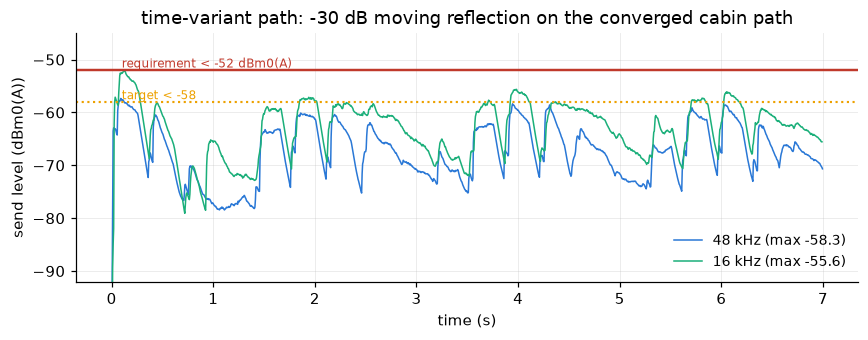

**The remaining battery rows — all criteria met; on the swing/three-phase rows the rescue's shadow trigger fires after the louder-direction return legs, and the deep steadies that land inside the fixed read windows are regression-gated at the rescued values.**

| G.168-adapted row (criterion) | 48 kHz | 16 kHz |
|---|---|---|
| 2C convergence in noise: echo ≤ noise gen. by 1 s (dBm0) | -34.4 vs -29.1 | -32.7 vs -28.8 |
| 3A low near end must not block adaptation (out vs near end, dBm0) | -31.5 vs -30.8 | -32.8 vs -28.6 |
| 3B divergence during 0 dB double talk: LRES after (≤ Fig 11 + 5 = -38.3) | -62.6 | -67.0 |
| 3C conversational alternation: worst post-DT peak (≤ -20 dBm0) | -24.9 | -22.1 |
| 4 leak rate: residual before → after 45 s silence (≤ +5 dB) | -82.5 → -84.8 | -96.5 → -97.4 |
| 5A path opened: combined loss held (≥ 20 dB) | 46.1 | 46.8 |
| 5B coupling swings 6 ↔ 46 dB: worst steady after return (gate) | -36.9 | -57.5 |
| 6 DTMF tones don't corrupt: residual after (≤ Fig 11 - 6 = -49.3) | -76.8 | -91.5 |
| 7 30 s 1 kHz tone: max residual after 10 s (≤ -49.3 dBm0) | -245.5 | -106.4 |
| 12 three-phase A→B→A: first-second loss each phase (≥ 6 dB) | 10.2 | 13.3 |

In [11]:
fig, ax = plt.subplots(figsize=(8, 3.2))
for r, col, lbl in ((R48, C48, "48 kHz"), (R16, C16, "16 kHz")):
    t, v = trace(r["tvp"]["trace"])
    ax.plot(t, v, color=col, lw=1.0, label=f"{lbl} (max {r['tvp']['max_lvl']:.1f})")
ax.axhline(-52, color=C_REQ, lw=1.6); ax.annotate("requirement < -52 dBm0(A)", (0.1, -51.5), fontsize=8, color=C_REQ)
ax.axhline(-58, color=C_TGT, ls=":", lw=1.4); ax.annotate("target < -58", (0.1, -57.5), fontsize=8, color=C_TGT)
ax.set_ylim(-92, -45)
ax.set_xlabel("time (s)"); ax.set_ylabel("send level (dBm0(A))")
ax.set_title("time-variant path: -30 dB moving reflection on the converged cabin path")
ax.legend(fontsize=9, frameon=False, loc="lower right")
plt.tight_layout(); plt.show()

def g168_rows(key, fmtv=m1):
    return [fmtv(R48["g168"][key]), fmtv(R16["g168"][key])]

l = -16.0
rows = [
    ["2C convergence in noise: echo ≤ noise gen. by 1 s (dBm0)",
     f"{R48['g168']['noise_conv_max']:.1f} vs {R48['g168']['noise_conv_lsgen']:.1f}",
     f"{R16['g168']['noise_conv_max']:.1f} vs {R16['g168']['noise_conv_lsgen']:.1f}"],
    ["3A low near end must not block adaptation (out vs near end, dBm0)",
     f"{R48['g168']['low_near_late']:.1f} vs {R48['g168']['low_near_vmax']:.1f}",
     f"{R16['g168']['low_near_late']:.1f} vs {R16['g168']['low_near_vmax']:.1f}"],
    ["3B divergence during 0 dB double talk: LRES after (≤ Fig 11 + 5 = -38.3)", *g168_rows("dt_div_lres")],
    ["3C conversational alternation: worst post-DT peak (≤ -20 dBm0)", *g168_rows("altern_worst")],
    ["4 leak rate: residual before → after 45 s silence (≤ +5 dB)",
     f"{R48['g168']['leak_before']:.1f} → {R48['g168']['leak_after']:.1f}",
     f"{R16['g168']['leak_before']:.1f} → {R16['g168']['leak_after']:.1f}"],
    ["5A path opened: combined loss held (≥ 20 dB)", *g168_rows("inf_erl_loss")],
    ["5B coupling swings 6 ↔ 46 dB: worst steady after return (gate)", *g168_rows("swings_worst")],
    ["6 DTMF tones don't corrupt: residual after (≤ Fig 11 - 6 = -49.3)", *g168_rows("narrowband_after")],
    ["7 30 s 1 kHz tone: max residual after 10 s (≤ -49.3 dBm0)", *g168_rows("tone_max")],
    ["12 three-phase A→B→A: first-second loss each phase (≥ 6 dB)",
     m1(min(R48["g168"]["three_phase_loss"])), m1(min(R16["g168"]["three_phase_loss"]))],
]
table(["G.168-adapted row (criterion)", "48 kHz", "16 kHz"], rows,
      "The remaining battery rows — all criteria met; on the swing/three-phase rows the rescue's "
      "shadow trigger fires after the louder-direction return legs, and the deep steadies that "
      "land inside the fixed read windows are regression-gated at the rescued values.")

Leak rate deserves a sentence: after 45 s of silence the residual
*improves* — the Kalman's state decay (transition 0.9998 per block) is a
modeled leak, and with no excitation the uncertainty tracker simply
holds; there is no NLMS-style drift to leak away.

## 8. Stability and delay

P.1110 Annex E closes the loop: the far end reflects the send signal
back (an echoey far-end terminal), the reflection's ERL swept 50 → 0 dB
in 5 dB steps — at 0 dB the far end returns *everything*. Stability
with near-end speech driving, chain reset at each step.


In [12]:
rows = []
for r, lbl in ((R48, "48 kHz"), (R16, "16 kHz")):
    st = r["stability"]
    n_stable = sum(st["stable"])
    min_erl = min(e for e, s in zip(st["erl"], st["stable"]) if s)
    verdict = "stable at every step" if n_stable == len(st["erl"]) else "UNSTABLE STEPS PRESENT"
    rows.append([lbl, f"{st['erl'][0]:.0f} → {st['erl'][-1]:.0f} dB", verdict, f"{min_erl:.0f} dB",
                 f"{r['delay_ms']:.1f} ms"])
table(["rate", "far-end ERL sweep", "closed-loop verdict", "minimum stable far-end ERL",
       "algorithmic delay (budget 70 ms, target 35)"], rows,
      "Annex E stability sweep and the delay report.")

**Annex E stability sweep and the delay report.**

| rate | far-end ERL sweep | closed-loop verdict | minimum stable far-end ERL | algorithmic delay (budget 70 ms, target 35) |
|---|---|---|---|---|
| 48 kHz | 50 → 0 dB | stable at every step | 0 dB | 10.7 ms |
| 16 kHz | 50 → 0 dB | stable at every step | 0 dB | 32.0 ms |

## 9. The G.167 historical row

G.167 (03/93) is withdrawn and its acoustic-echo-controller values are
bracketed (provisional), so this row is **run and reported** — never
claimed as compliance. 48 kHz, unit-energy cabin (the worst-case
coupling in the battery).

One finding matters here: **TCLwdt** (echo loss during double talk)
reads low against the bracketed [30]/[25] not because echo returns —
the reading is *invariant to ±10 dB of echo-path scaling*, which real
echo cannot be. What the comb measurement picks up in the far-end bands
during double talk is near-end **gain-modulation spill** through the
suppressor, not echo. Under P.1110's reading of the same quantity
(≥ 37 dB) the chain passes comfortably; the suite gates the G.167 row
at the measured value as a regression check.


In [13]:
g = D["g167"]
rows = [
    ["TCLwst — single-talk terminal coupling loss", "≥ [45] dB", f"{g['tclwst']:.1f} dB"],
    ["Tic — initial convergence, ERL within 1 s", "≥ [20] dB", f"{g['tic']:.1f} dB"],
    ["TCLwdt — echo loss during double talk", "≥ [30] dB (see note)", f"{g['tclwdt']:.1f} dB"],
    ["Asdt — send attenuation during double talk", "≤ 6 dB", f"{g['asdt']:.1f} dB"],
    ["processing delay per direction", "≤ [16] ms", f"{g['delay_ms']:.1f} ms"],
]
table(["G.167 figure (hands-free)", "bracketed value", "measured"], rows,
      "Run and reported: the recommendation is withdrawn; bracketed values were never finalized.")

**Run and reported: the recommendation is withdrawn; bracketed values were never finalized.**

| G.167 figure (hands-free) | bracketed value | measured |
|---|---|---|
| TCLwst — single-talk terminal coupling loss | ≥ [45] dB | 61.6 dB |
| Tic — initial convergence, ERL within 1 s | ≥ [20] dB | 39.5 dB |
| TCLwdt — echo loss during double talk | ≥ [30] dB (see note) | 23.6 dB |
| Asdt — send attenuation during double talk | ≤ 6 dB | 0.9 dB |
| processing delay per direction | ≤ [16] ms | 10.7 ms |

## What this proves, and where the teeth are

- Every **ITU requirement** row measured above is met at both required
  rates, on one pinned configuration, with the margins shown. Our own
  stricter targets are met almost everywhere; the misses — 16 kHz
  temporal stability, the 600 ms half-time convergence point, 16 kHz
  hangover at +0.5 s, pumping-in-driving-noise ≤ 5 — are each marked
  (T) above with the trade that bought them.
- The enforcement lives in the **test suite**, not this notebook:
  [`tests/test_itu_echo.cpp`](../tests/test_itu_echo.cpp),
  [`test_itu_doubletalk.cpp`](../tests/test_itu_doubletalk.cpp),
  [`test_itu_dynamics.cpp`](../tests/test_itu_dynamics.cpp) and
  [`test_g168.cpp`](../tests/test_g168.cpp) assert every row with
  measured-first thresholds, and CI runs them on every change. This
  notebook exists so a human can *see* the trajectories the assertions
  compress into pass/fail.
- The former deviation — slow deep re-convergence after abrupt path
  changes, structural in a converged Kalman — is closed by the
  two-trigger rescue above in both directions, with regression gates
  holding the rescued trajectories. What remains open is margin work,
  not compliance: the 16 kHz hangover and time-variant-path rows pass
  with thin margins that the rescue does not move (slow drift and
  post-double-talk drag never look like an abrupt swap), filed in
  [`HANDOFF.md`](../HANDOFF.md).

**Recommendations:** ITU-T P.1110/P.1120 (in-force automotive wideband/
super-wideband), P.340 (02/2000) Table 5 Category 1, P.501 (test
signals), G.168 (2015, structure adapted to acoustic paths), G.167
(03/93, historical). The requirements matrix with clause-level notes:
[`docs/itu-compliance.md`](../docs/itu-compliance.md).
